# Prueba del Modelo de Regresión Logística

Se buscó replicar lo hecho en la Libreta 006:

1. Cargar un nuevo data set, en el que los datos se encuentran balanceados.
2. Separar variables predictoras y variable objetivo.
3. Dividir los datos en entrenamiento y prueba.
4. Construir un primer modelo baseline de regresión logística.
5. Obtener predicciones de clase y probabilidades.
6. Evaluar el desempeño del modelo con métricas básicas.
7. Interpretar los primeros resultados.

Importamos las librerias que vamos a utilizar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## Cargamos el dataset balanceado

In [2]:
f = "../data/default_credit_balanced.csv" # ruta al archivo CSV
df = pd.read_csv(f)
# Renombrado de columnas
df = df.rename(columns={"PAY_0": "PAY_1"})
df.head()

,ORIGINAL_ID,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL,AGE_GROUP
0,22083,1,90000,2,1,2,28,0,0,0,2,2,2,38355,39413,41181,41701,44000,45651,1700,2404,1500,3000,2500,600,0,Femenino,Posgrado,Soltero,20-29
1,20843,2,180000,1,1,1,40,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1,Masculino,Posgrado,Casado,40-49
2,6774,3,470000,2,2,2,32,0,0,0,0,0,0,491428,488642,485382,360959,338592,123737,300000,15937,11891,120000,6380,250000,1,Femenino,Universidad,Soltero,30-39
3,17389,4,130000,2,2,2,44,2,0,0,2,2,2,72181,73086,78411,79725,81311,83048,2700,6500,3200,3500,3200,3300,1,Femenino,Universidad,Soltero,40-49
4,17378,5,210000,2,1,1,38,1,-2,-1,-1,-1,-1,0,0,517,-1,932,1066,0,517,0,933,1066,462,0,Femenino,Posgrado,Casado,30-39


Hacemos una revisión rapida de la estructura del dataset.

In [3]:
print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

Dimensiones: (30000, 30)

Columnas:
['ORIGINAL_ID', 'ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_next_month', 'SEX_LABEL', 'EDUCATION_LABEL', 'MARRIAGE_LABEL', 'AGE_GROUP']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ORIGINAL_ID         30000 non-null  int64
 1   ID                  30000 non-null  int64
 2   LIMIT_BAL           30000 non-null  int64
 3   SEX                 30000 non-null  int64
 4   EDUCATION           30000 non-null  int64
 5   MARRIAGE            30000 non-null  int64
 6   AGE                 30000 non-null  int64
 7   PAY_1               30000 non-null  int64
 8   PAY_2               30000 non-null  int64
 9   PAY_3               30000 non-null  int64
 10  PAY_4               30000 non-null  int64
 11  PAY_5               30000 non-null  int64
 12  PAY_6               30000 non-null  int64
 13  BILL_AMT1           30000 non-null  int64
 14  BILL_AMT2           30000 non-null  int64
 15  BILL_AMT3           30000 non-null  int64
 16  BILL_AMT4           30000 non-null  int64
 17  BILL

## Separación de predictores y variable objetivo

La variable objetivo es `default_next_month`, mientras que el resto de las variables serán consideradas como predictores.

Se excluyen las columnas auxiliares de texto o etiquetas, así como el identificador `ID`.

In [5]:
cols_to_drop = ["default_next_month"]

optional_drop = ["ID", "SEX_LABEL", 'EDUCATION_LABEL', 'MARRIAGE_LABEL', 'AGE_GROUP' ]
for col in optional_drop:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df["default_next_month"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (30000, 24)
Dimensiones de y: (30000,)


## Distribución de la variable objetivo

Antes de entrenar el modelo, es importante revisar qué tan balanceadas están las clases.

In [6]:
target_dist = y.value_counts().sort_index().to_frame("count")
target_dist["proportion"] = y.value_counts(normalize=True).sort_index()
target_dist

,count,proportion
default_next_month,,
0,17400,0.5800
1,12600,0.4200


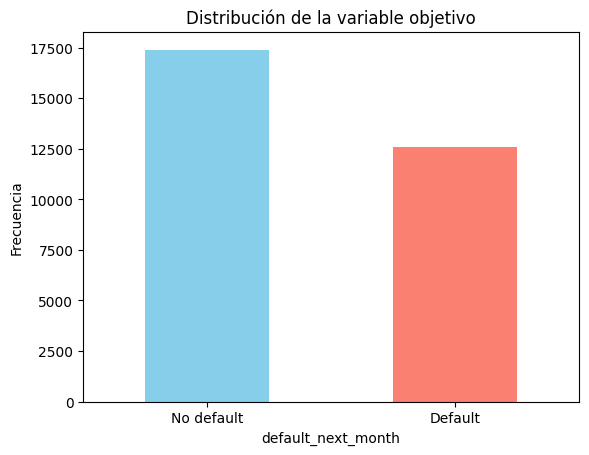

In [7]:
# Visualización de la distribución de la variable objetivo
y.value_counts().sort_index().plot(kind="bar", color=["skyblue", "salmon"])
plt.xticks([0, 1], ["No default", "Default"], rotation=0)
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable objetivo")
plt.show()

Se puede observar

## División en entrenamiento y prueba

Se divide el conjunto de datos en dos partes:

- **entrenamiento**: para ajustar el modelo,
- **prueba**: para evaluar su desempeño en datos no vistos.

Se utiliza partición estratificada para conservar aproximadamente la misma proporción de clases en ambos subconjuntos.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24000, 24)
X_test : (6000, 24)
y_train: (24000,)
y_test : (6000,)


## Identificación de variables numéricas y categóricas

Para construir el pipeline de preprocesamiento, se distinguieron las variables numéricas y categóricas.

In [9]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
categorical_features = [col for col in categorical_features if col in X_train.columns]

numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Variables categóricas:")
print(categorical_features)

print("\nVariables numéricas:")
print(numeric_features)

Variables categóricas:
['SEX', 'EDUCATION', 'MARRIAGE']

Variables numéricas:
['ORIGINAL_ID', 'LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## Preprocesamiento

Se aplican transformaciones distintas según el tipo de variable:

- **numéricas**: imputación por mediana y escalamiento.
- **categóricas**: imputación por moda y codificación one-hot.

Este paso se integra en un pipeline para evitar fugas de información y mantener el flujo de trabajo ordenado.

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Modelo baseline: regresión logística

Se construye una regresión logística como primer modelo baseline para predecir incumplimiento.

In [11]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

## Entrenamiento del modelo

In [12]:
log_reg.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['ORIGINAL_ID','LIMIT_BAL','SEX',...,'PAY_AMT4','PAY_AMT5','PAY_AMT6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

## Predicciones del modelo

Se obtienen:

- predicciones de clase (`0` o `1`),
- probabilidades estimadas de incumplimiento.

In [13]:
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

## Evaluación del modelo

Se calculan métricas básicas para evaluar el desempeño del clasificador en el conjunto de prueba.

In [14]:
metrics_dict = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

pd.DataFrame(metrics_dict, index=["Logistic Regression"]).T

,Logistic Regression
Accuracy,0.7113
Precision,0.7394
Recall,0.4829
F1-score,0.5843
ROC-AUC,0.7159


In [15]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7007    0.8767    0.7789      3480
           1     0.7394    0.4829    0.5843      2520

    accuracy                         0.7113      6000
   macro avg     0.7201    0.6798    0.6816      6000
weighted avg     0.7170    0.7113    0.6972      6000



#### `accuracy` (Exactitud)
* **Valor:** **`0.7113` (71.13%)**
* De las 6,000 personas totales evaluadas, el modelo acertó en el 71% de los casos.
* Ya que en este caso el 58% de los clientes son buenos pagadores, si el modelo simplemente predijera "Nadie va a impagar" sacaría un 58% de exactitud. El salto al 71% demuestra que el algoritmo sí está logrando identificar patrones reales y supera la línea base, aunque todavía tiene margen de mejora.

#### La Clase 1 (Impago)
Aquí es donde se previene la pérdida de dinero.

* **`support` (2520):** Había 2,520 morosos reales en estos datos de prueba.
* **`recall` (0.4829 o 48.29%):** *El área de oportunidad del modelo.*
    * De esos 2,520 morosos reales, el modelo logró detectar a **1,217**.
    * A los otros **1,303** morosos se les escapó la alarma, el banco les aprobó la tarjeta y generaron pérdidas (*Falsos Negativos*). El modelo capta prácticamente a la mitad (un volado) de los casos de riesgo.
* **`precision` (0.7394 o 73.94%):** *El punto fuerte del modelo.*
    * **Traducción:** Cuando el modelo levanta una alerta y dice "Este cliente no va a pagar", tiene razón casi el 74% de las veces.
    * **Impacto:** El otro 26% de las veces, se equivoca y acusa a un buen cliente de ser moroso, lo que significa que el banco le niega la tarjeta a alguien que sí iba a pagar (*Falsos Positivos*). Es un modelo cauteloso con sus acusaciones.
* **`f1-score` (0.5843):** Es el promedio armónico entre `precision` y `recall`. Al dejar de ser un modelo "ciego" (como ocurre en datos desbalanceados), este 0.58 nos indica un rendimiento general moderado o regular para detectar la clase minoritaria, frenado principalmente por el recall bajo.

#### La Clase 0 (Buen pagador)
El modelo sigue teniendo un buen desempeño en esta clase, pero sus métricas ahora reflejan que hay más equilibrio y menos sesgo.

* **`support` (3480):** Personas en los datos de prueba que realmente pagaron a tiempo.
* **`recall` (0.8767 o 87.67%):** De los 3,480 buenos clientes reales, el modelo identificó correctamente a la gran mayoría (aproximadamente **3,051**). Sigue haciendo un gran trabajo dejando pasar a los clientes confiables.
* **`precision` (0.7007 o 70.07%):** Cuando el modelo predice "Es un buen cliente", acierta el 70% de las veces. (El otro 30% representa a esos morosos que lograron "engañar" al modelo y se clasificaron como buenos clientes, es decir, nuestros Falsos Negativos).

#### Los Promedios Finales
* **`macro avg` (Promedio Macro):** Calcula el promedio simple entre la Clase 0 y la Clase 1. Como ahora los datos están bastante balanceados, este indicador es muy cercano a la realidad del modelo. Muestra un F1-Score general de **0.6816** (68.16%), lo que indica un desempeño moderado y mucho más estable que antes.
* **`weighted avg` (Promedio Ponderado):** Toma el promedio dándole peso al tamaño de cada clase (3480 vs 2520). A diferencia del dataset original (donde este número inflaba el rendimiento falsamente), aquí la diferencia con el promedio macro es mínima. Nos da un rendimiento global de **0.6972** (69.72%).

### Resumen 
El modelo ha corregido el sesgo hacia la clase mayoritaria que presentaba en el escenario del dataset original. Actualmente podemos decir que el modelo es **preciso, pero conservador**. Demuestra una alta capacidad para clasificar correctamente a los clientes confiables (Clase 0) y mantiene un bajo índice de falsos positivos al emitir alertas de impago (Precisión del 74%). 

No obstante, al utilizar el umbral de decisión predeterminado de 0.50, el algoritmo carece de la sensibilidad necesaria para maximizar la detección de la clase de mayor impacto financiero, omitiendo a poco más de la mitad de los clientes en situación de *default* (Recall del 48%). Para una aplicación real en la gestión de riesgo crediticio, la acción técnica recomendada es **calibrar y reducir el umbral de decisión** (por ejemplo, a 0.30 o 0.35). Este ajuste incrementará la sensibilidad del modelo, priorizando la detección de verdaderos positivos (morosos) para mitigar de manera más efectiva la exposición al riesgo del banco.

## Matriz de confusión

La matriz de confusión resume los aciertos y errores del modelo en cada clase.

In [16]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Real: No default", "Real: Default"],
    columns=["Pred: No default", "Pred: Default"]
)
cm_df

,Pred: No default,Pred: Default
Real: No default,3051,429
Real: Default,1303,1217


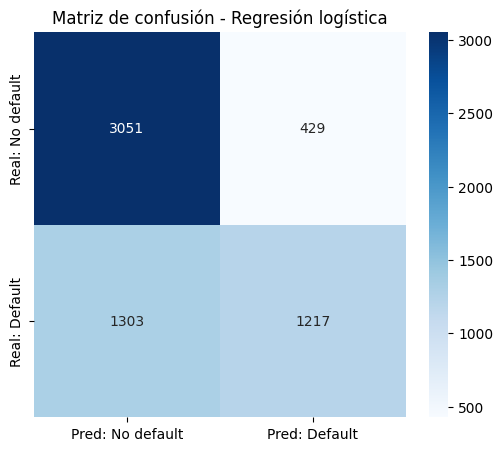

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Regresión logística")
plt.show()

#### Los Aciertos (La diagonal principal)
Representan las clasificaciones correctas realizadas por el modelo.

* **Cuadrante Superior Izquierdo (3,051) - Verdaderos Negativos:** * El modelo predijo correctamente que **3,051** clientes cumplirían con sus pagos ("No default"). 
  * Representan aprobaciones de crédito exitosas que generan ingresos sostenibles para la institución.
* **Cuadrante Inferior Derecho (1,217) - Verdaderos Positivos:**
  * El modelo identificó exitosamente a **1,217** clientes que efectivamente incurrieron en impago ("Default").
  * A diferencia del modelo con datos desbalanceados, este algoritmo demuestra una capacidad real de contención de riesgo, previniendo la asignación de crédito a una cantidad significativa de perfiles morosos.

#### Los Errores (Pérdidas y costos de oportunidad)
Representan las equivocaciones del clasificador, fundamentales para entender el margen de mejora del modelo.

* **Cuadrante Superior Derecho (429) - Falsos Positivos (Falsas Alarmas):**
  * El modelo predijo erróneamente un riesgo de impago para **429** clientes que en realidad resultaron ser cumplidos ("No default"). 
  * En términos de negocio, esto se traduce en una **pérdida de oportunidad comercial**, ya que el banco rechazaría solicitudes de clientes rentables. No obstante, en la gestión de riesgo crediticio, asumir este costo de oportunidad es preferible a asumir el costo de la deuda no recuperada.
* **Cuadrante Inferior Izquierdo (1,303) - Falsos Negativos (Riesgo No Detectado):**
  * El modelo clasificó como seguros a **1,303** clientes que finalmente incumplieron ("Default"). 
  * Este representa el **error financiero más crítico** para la institución, ya que se traduce directamente en capital prestado que pasará a cartera vencida. Aunque la proporción de morosos detectados mejoró drásticamente gracias al balance de las clases, esta cifra sustenta la recomendación técnica de reducir el umbral de decisión para priorizar la minimización de este cuadrante.

## Curva ROC

La curva ROC permite evaluar la capacidad discriminante del modelo en diferentes umbrales de clasificación.

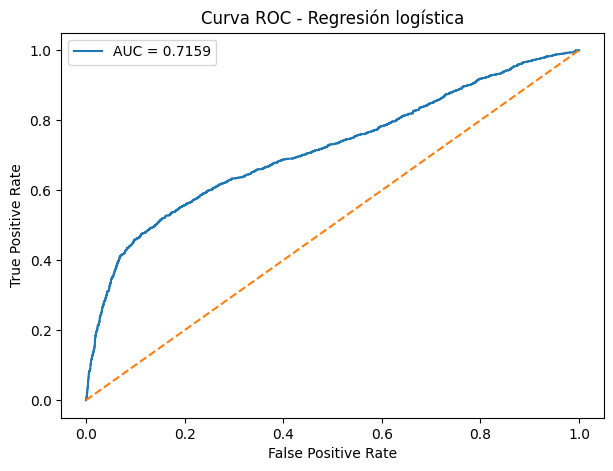

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión logística")
plt.legend()
plt.show()

La línea diagonal punteada representa el desempeño de un clasificador inútil que adivina al azar (AUC = 0.50), mientras que la línea continua azul demuestra la capacidad predictiva real de nuestro modelo.

En este caso, el modelo obtiene un **AUC (Área Bajo la Curva) de 0.7159**. Esto indica que, si seleccionamos aleatoriamente a un cliente que incurrió en *default* y a un cliente cumplido, existe un 71.6% de probabilidad de que el modelo le asigne un mayor nivel de riesgo al cliente moroso. 

**Análisis Comparativo y Conclusión Técnica:**
Es fundamental notar que este AUC (0.7159) es prácticamente idéntico al obtenido en escenarios con fuerte desbalance de clases. Esto reafirma una propiedad clave de la métrica ROC-AUC: evalúa la capacidad de discriminación intrínseca de las variables predictoras, independientemente de la proporción de las clases. 

En la industria de riesgos, un AUC de 0.716 se considera un rendimiento "moderado" o "aceptable". El hecho de que el balanceo de datos no haya elevado drásticamente este indicador sugiere que hemos alcanzado el límite predictivo lineal de la Regresión Logística con las características actuales. 

Para expandir esta curva hacia la zona de excelencia (esquina superior izquierda, acercando el AUC a 0.80 o superior), el paso analítico a seguir ya no es la manipulación de la muestra, sino la experimentación con algoritmos más potentes capaces de capturar relaciones no lineales (como *Random Forest* o *Gradient Boosting*) y la aplicación de ingeniería de características (*Feature Engineering*).

## Ejemplos de probabilidades predichas

Se revisan algunas probabilidades estimadas por el modelo para interpretar qué significa una salida probabilística.

In [19]:
results = X_test.copy()
results["y_real"] = y_test.values
results["y_pred"] = y_pred
results["prob_default"] = y_proba

print(results[["y_real", "y_pred", "prob_default"]].head(10))

       y_real  y_pred  prob_default
15436       0       0        0.3682
4380        0       1        0.6549
1208        0       0        0.4023
17661       0       0        0.2561
19893       1       1        0.7610
15512       1       1        0.7673
233         0       1        0.8880
18294       0       0        0.3840
4635        0       0        0.4357
7466        0       0        0.4944


Este bloque de código y su salida evidencian el impacto estadístico de haber entrenado al algoritmo con un conjunto de datos balanceado. Al contrastar el valor real (`y_real`), la clasificación final (`y_pred`) y la probabilidad calculada (`prob_default`), observamos un comportamiento predictivo dinámico y mucho más realista.

#### El fin del sesgo hacia la clase mayoritaria
A diferencia del modelo desbalanceado anterior, donde todas las predicciones en la muestra eran `0` debido a probabilidades artificialmente bajas, ahora observamos una **distribución amplia y equilibrada de probabilidades** (oscilando entre 25% y 88% tan solo en esta muestra). El modelo cruza el umbral de decisión del 0.50 (50%) con regularidad y clasifica activamente casos de riesgo en la Clase 1.

#### Identificación efectiva del riesgo (Verdaderos Positivos)
Analicemos a los clientes **19893** y **15512**:
* **`y_real = 1`:** Ambos clientes incurrieron efectivamente en impago.
* **`prob_default = ~0.76`:** El modelo evaluó sus historiales y les asignó una probabilidad de incumplimiento superior al 76%.
* **`y_pred = 1`:** Al superar holgadamente el 50%, el algoritmo emite la alerta correctamente. Esto confirma que el modelo ha aprendido con éxito a identificar los factores de riesgo de la clase minoritaria.

#### El costo de oportunidad (Falsos Positivos)
Observemos a los clientes **4380** y **233**:
* El modelo calculó probabilidades de riesgo elevadas (65.49% y 88.80% respectivamente), provocando una clasificación de impago (`y_pred = 1`).
* Sin embargo, en la realidad estos clientes resultaron ser cumplidos (`y_real = 0`). 
Estos casos representan los **Falsos Positivos** (las falsas alarmas) que contabilizamos previamente en la matriz de confusión. Reflejan un clasificador que, ante señales de riesgo crediticio, opta por la precaución. En el contexto bancario, asumir el costo de rechazar a un cliente limítrofe es estadísticamente preferible a otorgar crédito irrecuperable.

#### La sensibilidad del umbral de decisión
El cliente **7466** es un ejemplo perfecto de la rigidez matemática del límite de clasificación. Su `prob_default` es de **0.4944 (49.44%)**. Por un margen mínimo del 0.56%, el algoritmo lo mantiene catalogado como un cliente seguro (`y_pred = 0`). Este caso ilustra claramente la justificación técnica de la recomendación anterior: si el área de riesgos del banco decidiera ajustar el umbral operativo al 45% o 40%, clientes con perfiles límite como este serían reclasificados como morosos preventivos, permitiendo atrapar esos Falsos Negativos que aún se logran fugar.

## Inspección preliminar de coeficientes

En regresión logística, los coeficientes indican la dirección de la asociación entre cada predictor y la probabilidad de incumplimiento, manteniendo fijas las demás variables.

Esta interpretación debe hacerse con cautela, especialmente después de transformaciones y codificación de variables categóricas.

In [20]:
feature_names_num = numeric_features

ohe = log_reg.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([feature_names_num, feature_names_cat])

coefficients = log_reg.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

print(coef_df.head(15))

        feature  coefficient
3         PAY_1       0.6633
11    BILL_AMT3       0.1893
4         PAY_2       0.1245
5         PAY_3       0.0985
12    BILL_AMT4       0.0821
13    BILL_AMT5       0.0597
2           AGE       0.0580
7         PAY_5       0.0265
19     PAY_AMT5       0.0245
6         PAY_4       0.0171
8         PAY_6       0.0067
0   ORIGINAL_ID      -0.0117
20     PAY_AMT6      -0.0217
17     PAY_AMT3      -0.0223
22  EDUCATION_2      -0.0526


### Análisis de los Resultados (Modelo Balanceado)

Los coeficientes de la Regresión Logística revelan la lógica interna del algoritmo. Cada variable suma puntos (riesgo) o resta puntos (protección) a la probabilidad final de que un cliente incurra en impago.

**A. El Factor de Riesgo Absoluto: `PAY_1` (0.6633)**
* Se mantiene como el indicador más crítico del modelo. Su peso es abrumadoramente superior al resto.
* Representa el estado de pago del mes más reciente. 
* **Interpretación:** El algoritmo confirma que el comportamiento financiero a corto plazo es el predictor más fuerte. Un cliente que ya presenta un atraso en su último corte tiene una altísima probabilidad matemática de consolidar el impago el mes siguiente.

**B. La carga de la deuda y atrasos históricos: `BILL_AMT3`, `PAY_2`, `PAY_3`**
* A diferencia del modelo desbalanceado anterior, aquí los montos facturados han tomado una relevancia mayor, especialmente `BILL_AMT3` (0.1893).
* Los atrasos en los meses 2 y 3 (`PAY_2` con 0.1245 y `PAY_3` con 0.0985) siguen siendo alertas rojas importantes.
* **Interpretación:** El modelo penaliza severamente la acumulación de deuda histórica combinada con facturaciones altas en meses intermedios. Es el perfil de un cliente cuya deuda está creciendo como "bola de nieve".

**C. Los Factores de Protección (Coeficientes Negativos)**
* En la parte inferior encontramos variables que reducen la probabilidad de riesgo: `EDUCATION_2` (-0.0526), `PAY_AMT3` (-0.0223) y `PAY_AMT6` (-0.0217).
* **Interpretación:** Por un lado, realizar pagos efectivos en efectivo en meses pasados (`PAY_AMT`) sigue mitigando el riesgo. Por otro lado, el modelo ha detectado que pertenecer a la categoría `EDUCATION_2` (que típicamente representa nivel universitario) actúa como un factor demográfico de estabilidad que disminuye la probabilidad de *default*.

**D. Una alerta metodológica: `ORIGINAL_ID` (-0.0117)**
* La aparición de la variable `ORIGINAL_ID` en la lista de coeficientes es una anomalía técnica. 
* Los identificadores únicos (IDs) son números secuenciales asignados administrativamente y no contienen ninguna información real sobre el comportamiento financiero del cliente. 
* **Interpretación:** Su presencia indica una "fuga de datos" (*data leakage*) desde la etapa de preprocesamiento. El modelo intentó encontrarle un patrón matemático a un número de folio, asignándole un ligero peso protector. En un entorno de producción, este tipo de variables estructuradas deben ser eliminadas antes del entrenamiento para no introducir "ruido" matemático.